In [1]:
import pandas as pd
import plotly.express as px # pip install plotly-express
import matplotlib.pyplot as plt # pip install matplotlib
import seaborn as sns # pip install seaborn
from bankingsdk import DemandeClient, BankConfig

import time


In [2]:
"""## Se familiariser avec l'API"""

# Connexion à l'API via le SDK

config = BankConfig(bank_base_url="https://api-risk-credit.onrender.com")
client = DemandeClient(config=config)

# Vérification que l'API est opérationnelle
client.health_check()

BANK_API_BASE_URL in BankConfig init: https://api-risk-credit.onrender.com


{'message': 'API Credit Risk opérationnelle'}

In [3]:
"""On explore les données comme le ferait un Data Analyst."""

# Récupération d’une demande pour test
# Récupération des demandes via l’API
demande_df = client.list_demandes()  # suppose que ton SDK implémente cette méthode
# Récupération d’une demande pour test
demande_df = client.get_demande(9)
print(f"Agence : {demande_df.numero_agence}")
print(f"Montant : {demande_df.montant_operation}")
print(f"Statut : {demande_df.accord}")
print(f"Statut : {demande_df.score_emprunteur}")



Agence : 5
Montant : 44502057
Statut : N
Statut : REFUS


In [4]:
"""Passons à l'Exploration de la table des agences (`agences`)."""

# On récupère une grande portion de la table (à ajuster selon la taille réelle)
agence_df = client.list_agences(limit=100, output_format="pandas")
agence_df.head()

agence_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   numero_agence  6 non-null      int64 
 1   ville          6 non-null      object
 2   adresse        6 non-null      object
dtypes: int64(1), object(2)
memory usage: 276.0+ bytes


In [5]:
"""Passons à l'Exploration de la table de la situation professionelle des clients (`situation_pro`)."""

# On récupère une grande portion de la table (à ajuster selon la taille réelle)
situation_pro_df = client.list_situation_pros(limit=100, output_format="pandas")
situation_pro_df.head()

situation_pro_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   numero_client            100 non-null    int64 
 1   revenu_mensuel_moyen     100 non-null    int64 
 2   code_regularite_revenus  100 non-null    int64 
 3   regularite_des_revenus   100 non-null    object
 4   code_statut_emploi       100 non-null    int64 
 5   regularite_emploi        100 non-null    object
dtypes: int64(4), object(2)
memory usage: 4.8+ KB


In [6]:
"""Passons à l'Exploration de la table de la situation familiale des clients (`situation_famille`)."""

# On récupère une grande portion de la table (à ajuster selon la taille réelle)
situation_famille_df = client.list_situations_famille(limit=100, output_format="pandas")
situation_famille_df.head()

situation_famille_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   numero_client      100 non-null    int64 
 1   statut_familliale  100 non-null    object
 2   nombre_enfants     100 non-null    int64 
 3   age                100 non-null    int64 
 4   nom_client         100 non-null    object
 5   statut_activite    100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [7]:
"""Passons à l'Exploration de la table des apporst des clients (`apports`)."""

# On récupère une grande portion de la table (à ajuster selon la taille réelle)
apport_df = client.list_apports(limit=100, output_format="pandas")
apport_df.head()

apport_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   numero_demande  100 non-null    int64
 1   apport          100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


In [8]:
# Conversion via model_dump()
demande_df = pd.DataFrame([d.model_dump() for d in client.list_demandes()])

# Maintenant tu peux utiliser pandas normalement
user_counts = demande_df['numero_demande'].value_counts().reset_index()
user_counts


,numero_demande,count
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1
...,...,...
95,96,1
96,97,1
97,98,1
98,99,1


In [9]:
alldb_df = client.list_all_demandes(limit=100, output_format="pandas")
print(alldb_df.head())

   numero_demande  montant_operation  duree  date_de_demande  date_de_cloture  \
0               1           79902817    300   4 janvier 2018   2 février 2018   
1               2           81464270    300   4 janvier 2018  16 janvier 2018   
2               3           17654577    180  14 janvier 2018   9 février 2018   
3               4           60060984    180  22 janvier 2018  22 février 2018   
4               5          105950928    300  29 janvier 2018     18 mars 2018   

   numero_client accord  numero_agence  duree_de_traitement  code_accord  ...  \
0             84      N              2                   29            1  ...   
1             57      O              4                   12            2  ...   
2             40      O              6                   26            2  ...   
3             56      O              3                   31            2  ...   
4             49      O              4                   48            2  ...   

  regularite_des_revenus  

In [13]:
analytics = client.get_analytics()
print(analytics)

type(analytics)

demande_count=200 agence_count=6 situationpro_count=100 situationfamille_count=100 apport_count=200


bankingsdk.schemas.schemas.AnalyticsResponse

In [14]:
demande_df

,numero_demande,montant_operation,duree,date_de_demande,date_de_cloture,numero_client,accord,numero_agence,duree_de_traitement,code_accord,score_emprunteur,montant_prete
0,1,79902817,300,4 janvier 2018,2 février 2018,84,N,2,29,1,REFUS,55442771
1,2,81464270,300,4 janvier 2018,16 janvier 2018,57,O,4,12,2,ACCEPTE,64838909
2,3,17654577,180,14 janvier 2018,9 février 2018,40,O,6,26,2,ACCEPTE,14772197
3,4,60060984,180,22 janvier 2018,22 février 2018,56,O,3,31,2,ACCEPTE,47803641
4,5,105950928,300,29 janvier 2018,18 mars 2018,49,O,4,48,2,ACCEPTE,92977345
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,45454100,240,17 août 2019,5 octobre 2019,20,O,2,49,2,ACCEPTE,35250119
96,97,12947718,300,17 août 2019,30 septembre 2019,91,O,4,44,2,ACCEPTE,9512609
97,98,60929458,240,20 août 2019,5 septembre 2019,24,O,2,16,2,ACCEPTE,49738334
98,99,89090899,240,22 août 2019,11 septembre 2019,84,N,2,20,1,REFUS,56363630


In [15]:
print('* There are agence in {} numero_agence'.format(len(demande_df['numero_agence'].unique())))
print('* There are montant in {} montant_operation'.format(len(demande_df['montant_operation'].unique())))
print('* There are duree in {} duree'.format(len(demande_df['duree'].unique())))
print('* There are client in {} numero_client'.format(len(demande_df['numero_client'].unique())))
print('* There are accord in {} accord'.format(len(demande_df['accord'].unique())))
print('* There are duree_de_traitement in {} duree_de_traitement'.format(len(demande_df['duree_de_traitement'].unique())))
print('* There are score_emprunteur in {} score_emprunteur'.format(len(demande_df['score_emprunteur'].unique())))


* There are agence in 6 numero_agence
* There are montant in 100 montant_operation
* There are duree in 3 duree
* There are client in 63 numero_client
* There are accord in 2 accord
* There are duree_de_traitement in 50 duree_de_traitement
* There are score_emprunteur in 2 score_emprunteur


In [26]:
# cette fonction aide à regrouper et à tracer les demandes par différentes caractéristiques. 
#La fonction prend le nom de la caractéristique et les principales catégories dans chaque groupe à tracer.
def demande_plot_by_group(group, top=50, color='blue'):    
    demandes_by_group = demande_df.groupby(group)['montant_operation'].sum() # group demande by feature
    demandes_by_group.sort_values(ascending= False, inplace=True) # sort 
    demandes_by_group = demandes_by_group.head(top) # select top records
    plt.figure(figsize = (15,4)) 
    plt.title('Demandes par {}'.format(group))
    plt.ylabel('Demandes en XOF')
    plt.bar(demandes_by_group.index, demandes_by_group, color=color, alpha = 0.5)
    plt.xticks(rotation=90)
# add sum of sales for each bar and place it in the center of the bar
    for x,y in demandes_by_group.items():
        plt.text(x,demandes_by_group.max()/2, f'{int(y):,.0f}Xof', rotation=90, horizontalalignment='center', fontsize=12)
    plt.show


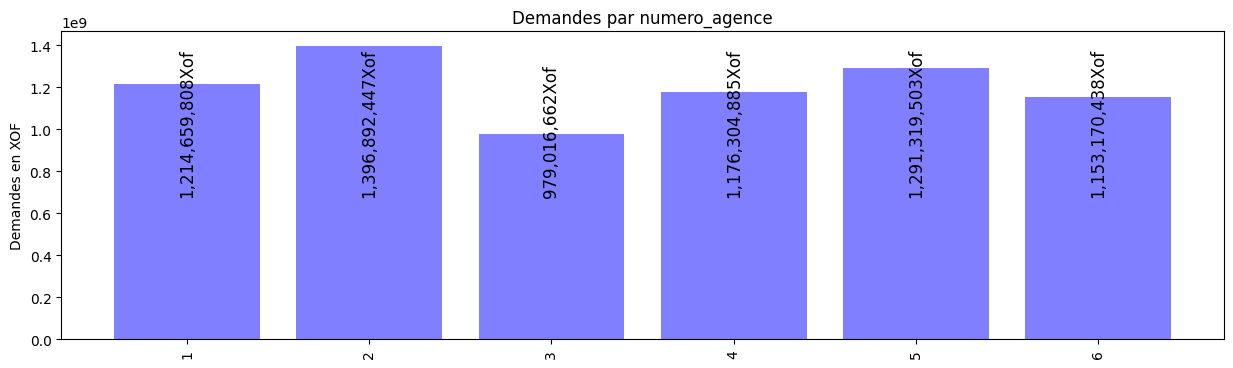

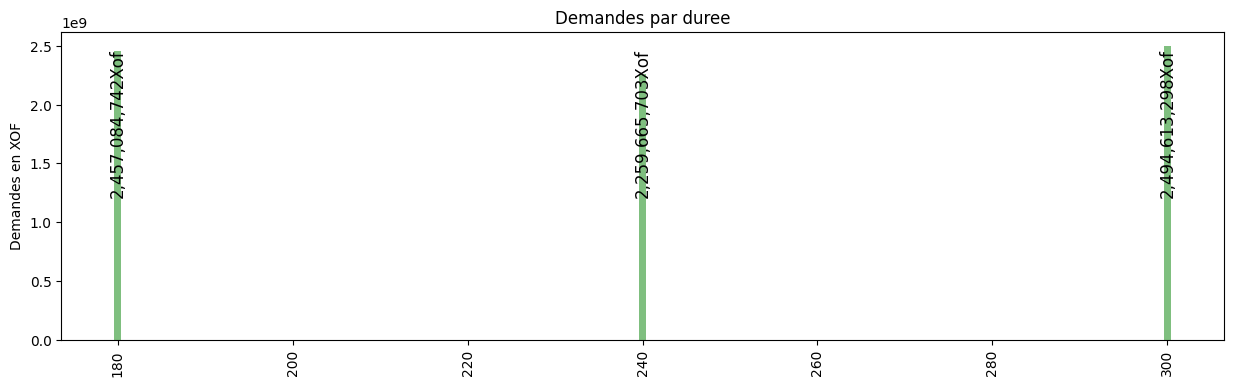

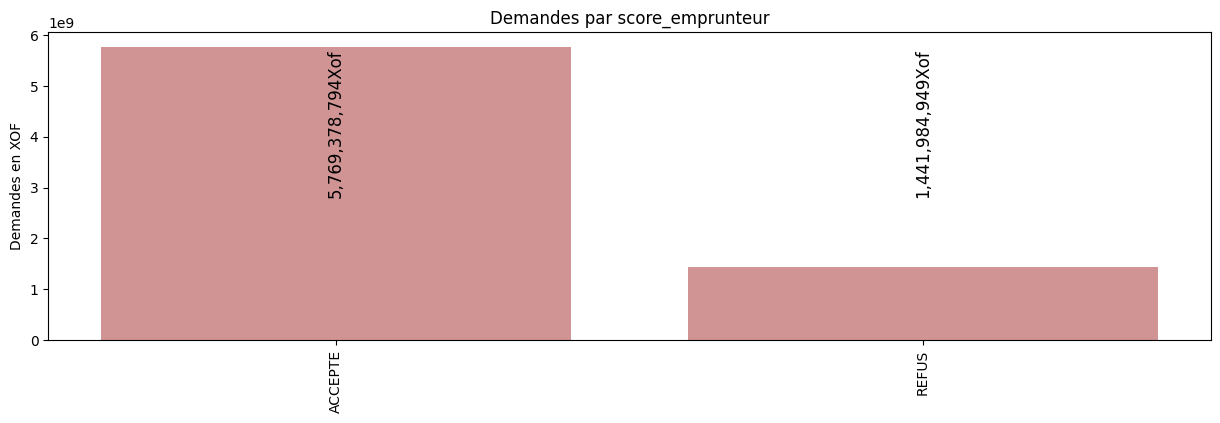

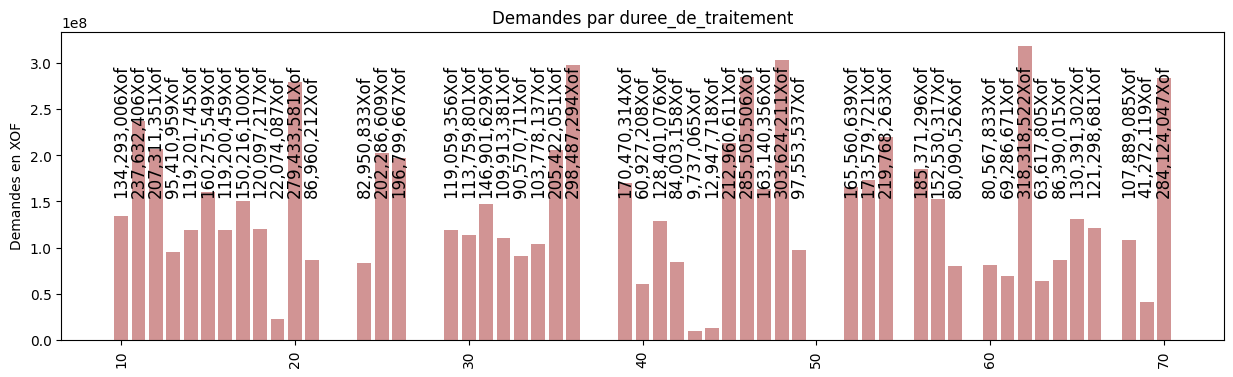

In [27]:
demande_plot_by_group('numero_agence',color='blue') # plot sales per state and show 20 top states
demande_plot_by_group('duree',color='green') # plot sales by sub-category
demande_plot_by_group('score_emprunteur',color='brown') # plot sales by ship mode
demande_plot_by_group('duree_de_traitement',color='brown') # plot sales by ship mode
